In [32]:
# ==========================================
# SALES & DISCOUNTS DATA ANALYSIS
# Descriptive Analytics & Visualization
# ==========================================

# ==========================================
# SECTION 1: SETUP & DATA LOADING
# ==========================================

print("="*60)
print("SECTION 1: SETUP & DATA LOADING")
print("="*60)

# Install required libraries (if needed)
# !pip install pandas numpy matplotlib seaborn scipy -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

# Load the dataset
# Option 1: Upload CSV file
#https://drive.google.com/file/d/1Tvno3LI0Bcz0B5eacf5qBJ-D4P7nKKXc/view?usp=sharing
file_id="1Tvno3LI0Bcz0B5eacf5qBJ-D4P7nKKXc"
url=f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)

print(f"\n✓ Dataset loaded: {url}")
print(f"✓ Total Records: {len(df)}")
print(f"✓ Total Columns: {len(df.columns)}")

# Display first few rows
print("\n" + "="*60)
print("FIRST 5 ROWS OF DATA")
print("="*60)
df.head()

SECTION 1: SETUP & DATA LOADING
✓ Libraries imported successfully

✓ Dataset loaded: https://drive.google.com/uc?id=1Tvno3LI0Bcz0B5eacf5qBJ-D4P7nKKXc
✓ Total Records: 450
✓ Total Columns: 13

FIRST 5 ROWS OF DATA


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [33]:
# ==========================================
# SECTION 2: DATA OVERVIEW & PREPROCESSING
# ==========================================

print("\n" + "="*60)
print("SECTION 2: DATA OVERVIEW & PREPROCESSING")
print("="*60)

# Basic information
print("\n📊 DATASET INFORMATION:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print("\n📋 DATA TYPES:")
print(df.dtypes)

print("\n🔍 MISSING VALUES:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n✓ Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"✓ Categorical Columns ({len(categorical_cols)}): {categorical_cols}")


SECTION 2: DATA OVERVIEW & PREPROCESSING

📊 DATASET INFORMATION:
Shape: (450, 13)
Columns: ['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

📋 DATA TYPES:
Date                  object
Day                   object
SKU                   object
City                  object
Volume                 int64
BU                    object
Brand                 object
Model                 object
Avg Price              int64
Total Sales Value      int64
Discount Rate (%)    float64
Discount Amount      float64
Net Sales Value      float64
dtype: object

🔍 MISSING VALUES:
Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

✓ Numerical 

In [34]:
# ==========================================
# SECTION 3: DESCRIPTIVE STATISTICS
# ==========================================

print("\n" + "="*60)
print("SECTION 3: DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES")
print("="*60)

# Select key numerical columns for analysis
analysis_cols = ['Volume', 'Avg Price', 'Total Sales Value',
                 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

def calculate_statistics(data, column):
    """Calculate comprehensive statistics for a column"""
    values = data[column].dropna()

    stats_dict = {
        'Mean': values.mean(),
        'Median': values.median(),
        'Mode': values.mode()[0] if len(values.mode()) > 0 else np.nan,
        'Std Dev': values.std(),
        'Variance': values.var(),
        'Min': values.min(),
        'Max': values.max(),
        'Q1 (25%)': values.quantile(0.25),
        'Q3 (75%)': values.quantile(0.75),
        'IQR': values.quantile(0.75) - values.quantile(0.25),
        'Range': values.max() - values.min(),
        'Skewness': values.skew(),
        'Kurtosis': values.kurtosis()
    }

    return stats_dict

# Calculate statistics for each column
print("\n📈 DETAILED STATISTICS:\n")

stats_results = {}
for col in analysis_cols:
    if col in df.columns:
        print(f"\n{'='*50}")
        print(f"📊 {col.upper()}")
        print('='*50)

        stats_dict = calculate_statistics(df, col)
        stats_results[col] = stats_dict

        # Print statistics
        for stat_name, stat_value in stats_dict.items():
            print(f"{stat_name:15} : {stat_value:,.4f}")

        # Interpretation
        print(f"\n💡 INTERPRETATION:")
        if col == 'Volume':
            print(f"   - Average sales volume: {stats_dict['Mean']:.2f} units")
            print(f"   - Volume varies by ±{stats_dict['Std Dev']:.2f} units")
        elif col == 'Discount Rate (%)':
            print(f"   - Average discount: {stats_dict['Mean']:.2f}%")
            print(f"   - Discount range: {stats_dict['Min']:.2f}% to {stats_dict['Max']:.2f}%")
        elif col == 'Total Sales Value':
            print(f"   - Average transaction: ₹{stats_dict['Mean']:,.2f}")
            print(f"   - High variability (Std Dev: ₹{stats_dict['Std Dev']:,.2f})")

# Create summary DataFrame
stats_df = pd.DataFrame(stats_results).T
print("\n" + "="*60)
print("SUMMARY STATISTICS TABLE")
print("="*60)
print(stats_df.round(2))




SECTION 3: DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES

📈 DETAILED STATISTICS:


📊 VOLUME
Mean            : 5.0667
Median          : 4.0000
Mode            : 3.0000
Std Dev         : 4.2316
Variance        : 17.9065
Min             : 1.0000
Max             : 31.0000
Q1 (25%)        : 3.0000
Q3 (75%)        : 6.0000
IQR             : 3.0000
Range           : 30.0000
Skewness        : 2.7317
Kurtosis        : 10.2585

💡 INTERPRETATION:
   - Average sales volume: 5.07 units
   - Volume varies by ±4.23 units

📊 AVG PRICE
Mean            : 10,453.4333
Median          : 1,450.0000
Mode            : 400.0000
Std Dev         : 18,079.9048
Variance        : 326,882,959.0212
Min             : 290.0000
Max             : 60,100.0000
Q1 (25%)        : 465.0000
Q3 (75%)        : 10,100.0000
IQR             : 9,635.0000
Range           : 59,810.0000
Skewness        : 1.9089
Kurtosis        : 2.0757

💡 INTERPRETATION:

📊 TOTAL SALES VALUE
Mean            : 33,812.8356
Median          : 5,700.0000



SECTION 4: HISTOGRAMS - DISTRIBUTION ANALYSIS


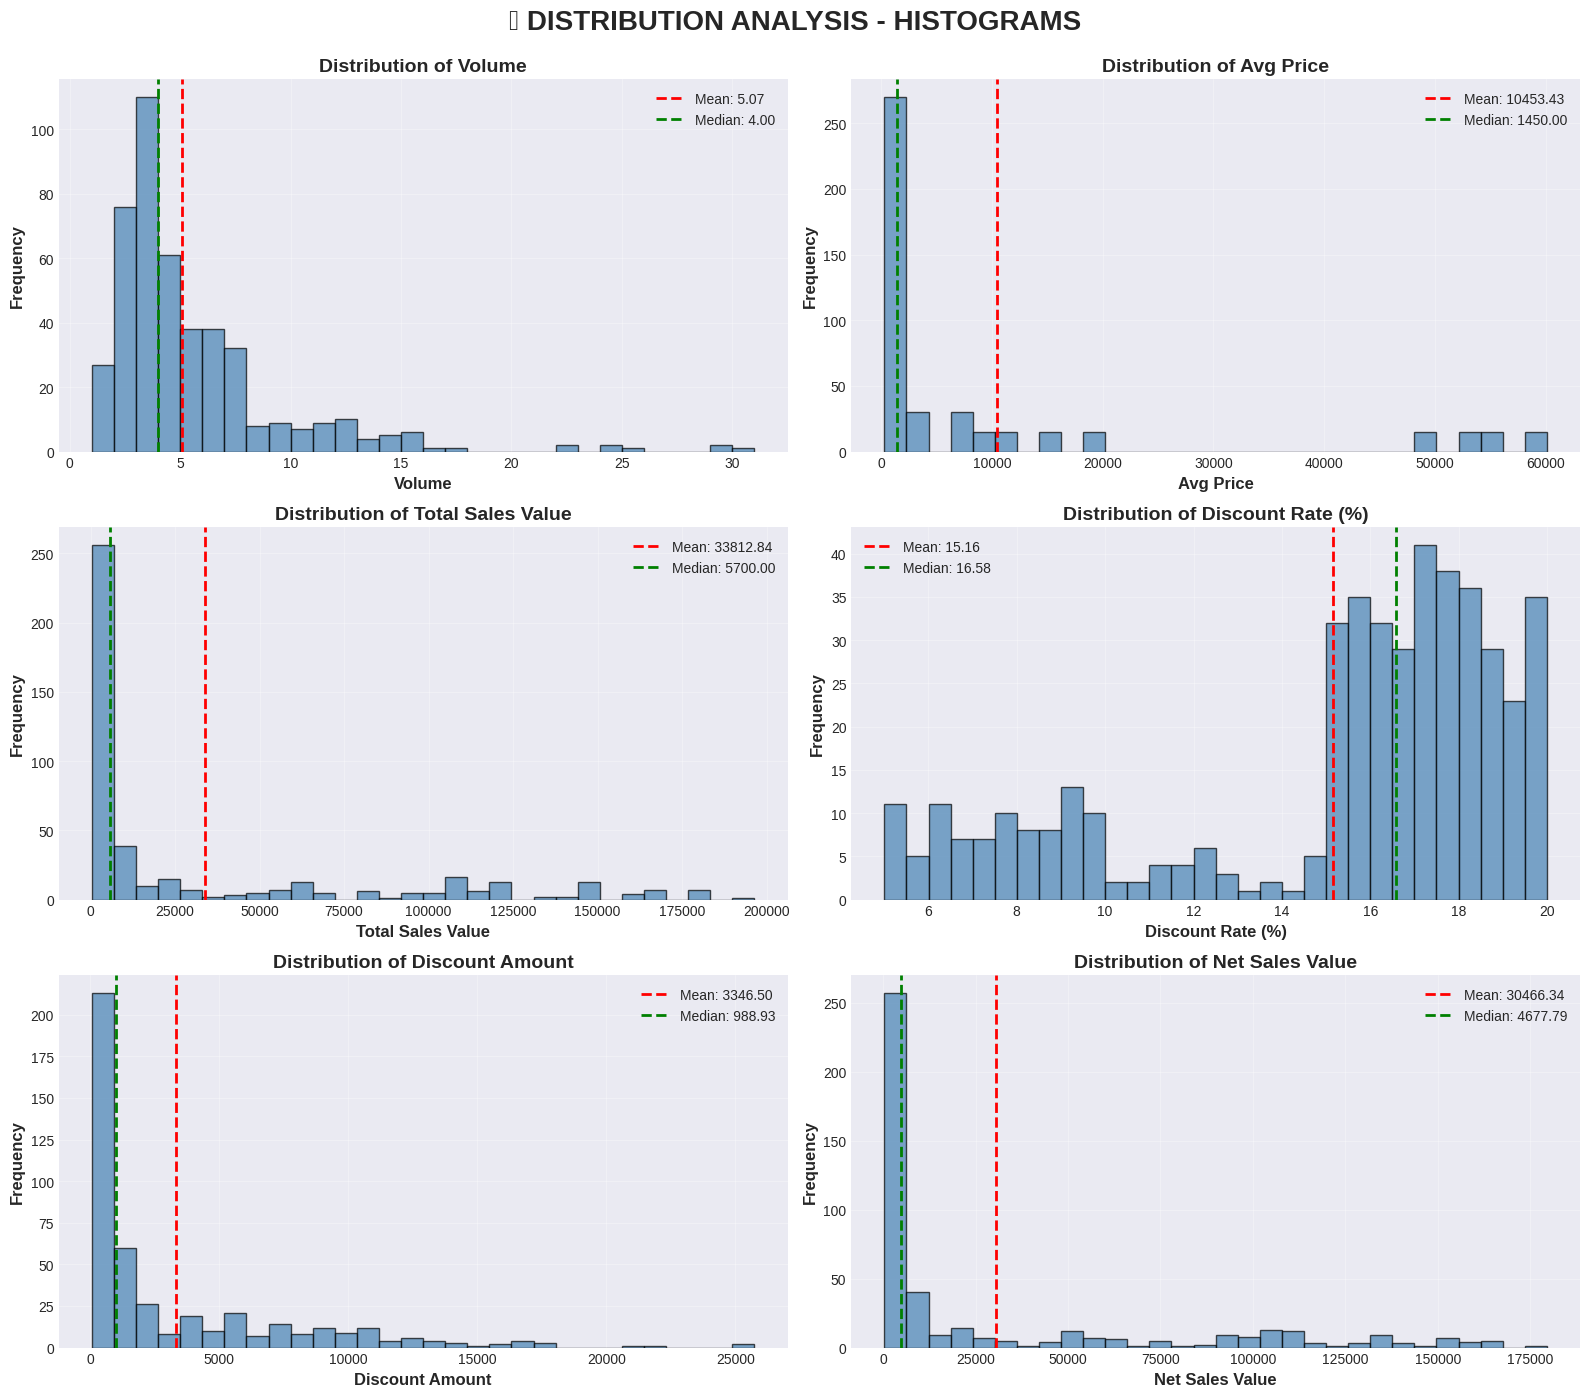


📊 DISTRIBUTION ANALYSIS:

Volume:
  - Skewness: 2.732 (Right-skewed - tail on right)
  - Kurtosis: 10.259 (Heavy tails - more outliers)

Avg Price:
  - Skewness: 1.909 (Right-skewed - tail on right)
  - Kurtosis: 2.076 (Heavy tails - more outliers)

Total Sales Value:
  - Skewness: 1.535 (Right-skewed - tail on right)
  - Kurtosis: 1.025 (Heavy tails - more outliers)

Discount Rate (%):
  - Skewness: -1.062 (Left-skewed - tail on left)
  - Kurtosis: -0.179 (Normal distribution)

Discount Amount:
  - Skewness: 1.913 (Right-skewed - tail on right)
  - Kurtosis: 3.831 (Heavy tails - more outliers)

Net Sales Value:
  - Skewness: 1.541 (Right-skewed - tail on right)
  - Kurtosis: 1.012 (Heavy tails - more outliers)


In [35]:
# ==========================================
# SECTION 4: HISTOGRAMS - DISTRIBUTION ANALYSIS
# ==========================================

print("\n" + "="*60)
print("SECTION 4: HISTOGRAMS - DISTRIBUTION ANALYSIS")
print("="*60)

# Create histograms for numerical columns
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('📊 DISTRIBUTION ANALYSIS - HISTOGRAMS',
             fontsize=20, fontweight='bold', y=0.995)

plot_cols = analysis_cols[:6]  # First 6 columns

for idx, col in enumerate(plot_cols):
    if col in df.columns:
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]

        # Plot histogram
        n, bins, patches = ax.hist(df[col].dropna(), bins=30,
                                    color='steelblue',
                                    edgecolor='black',
                                    alpha=0.7)

        # Add mean and median lines
        mean_val = df[col].mean()
        median_val = df[col].median()

        ax.axvline(mean_val, color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--',
                   linewidth=2, label=f'Median: {median_val:.2f}')

        # Formatting
        ax.set_xlabel(col, fontsize=12, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis of distribution patterns
print("\n📊 DISTRIBUTION ANALYSIS:")
for col in plot_cols:
    if col in df.columns:
        skew = df[col].skew()
        kurt = df[col].kurtosis()

        print(f"\n{col}:")
        print(f"  - Skewness: {skew:.3f}", end="")
        if abs(skew) < 0.5:
            print(" (Approximately Symmetric)")
        elif skew > 0:
            print(" (Right-skewed - tail on right)")
        else:
            print(" (Left-skewed - tail on left)")

        print(f"  - Kurtosis: {kurt:.3f}", end="")
        if abs(kurt) < 0.5:
            print(" (Normal distribution)")
        elif kurt > 0:
            print(" (Heavy tails - more outliers)")
        else:
            print(" (Light tails - fewer outliers)")


SECTION 5: BOX PLOTS - OUTLIER DETECTION


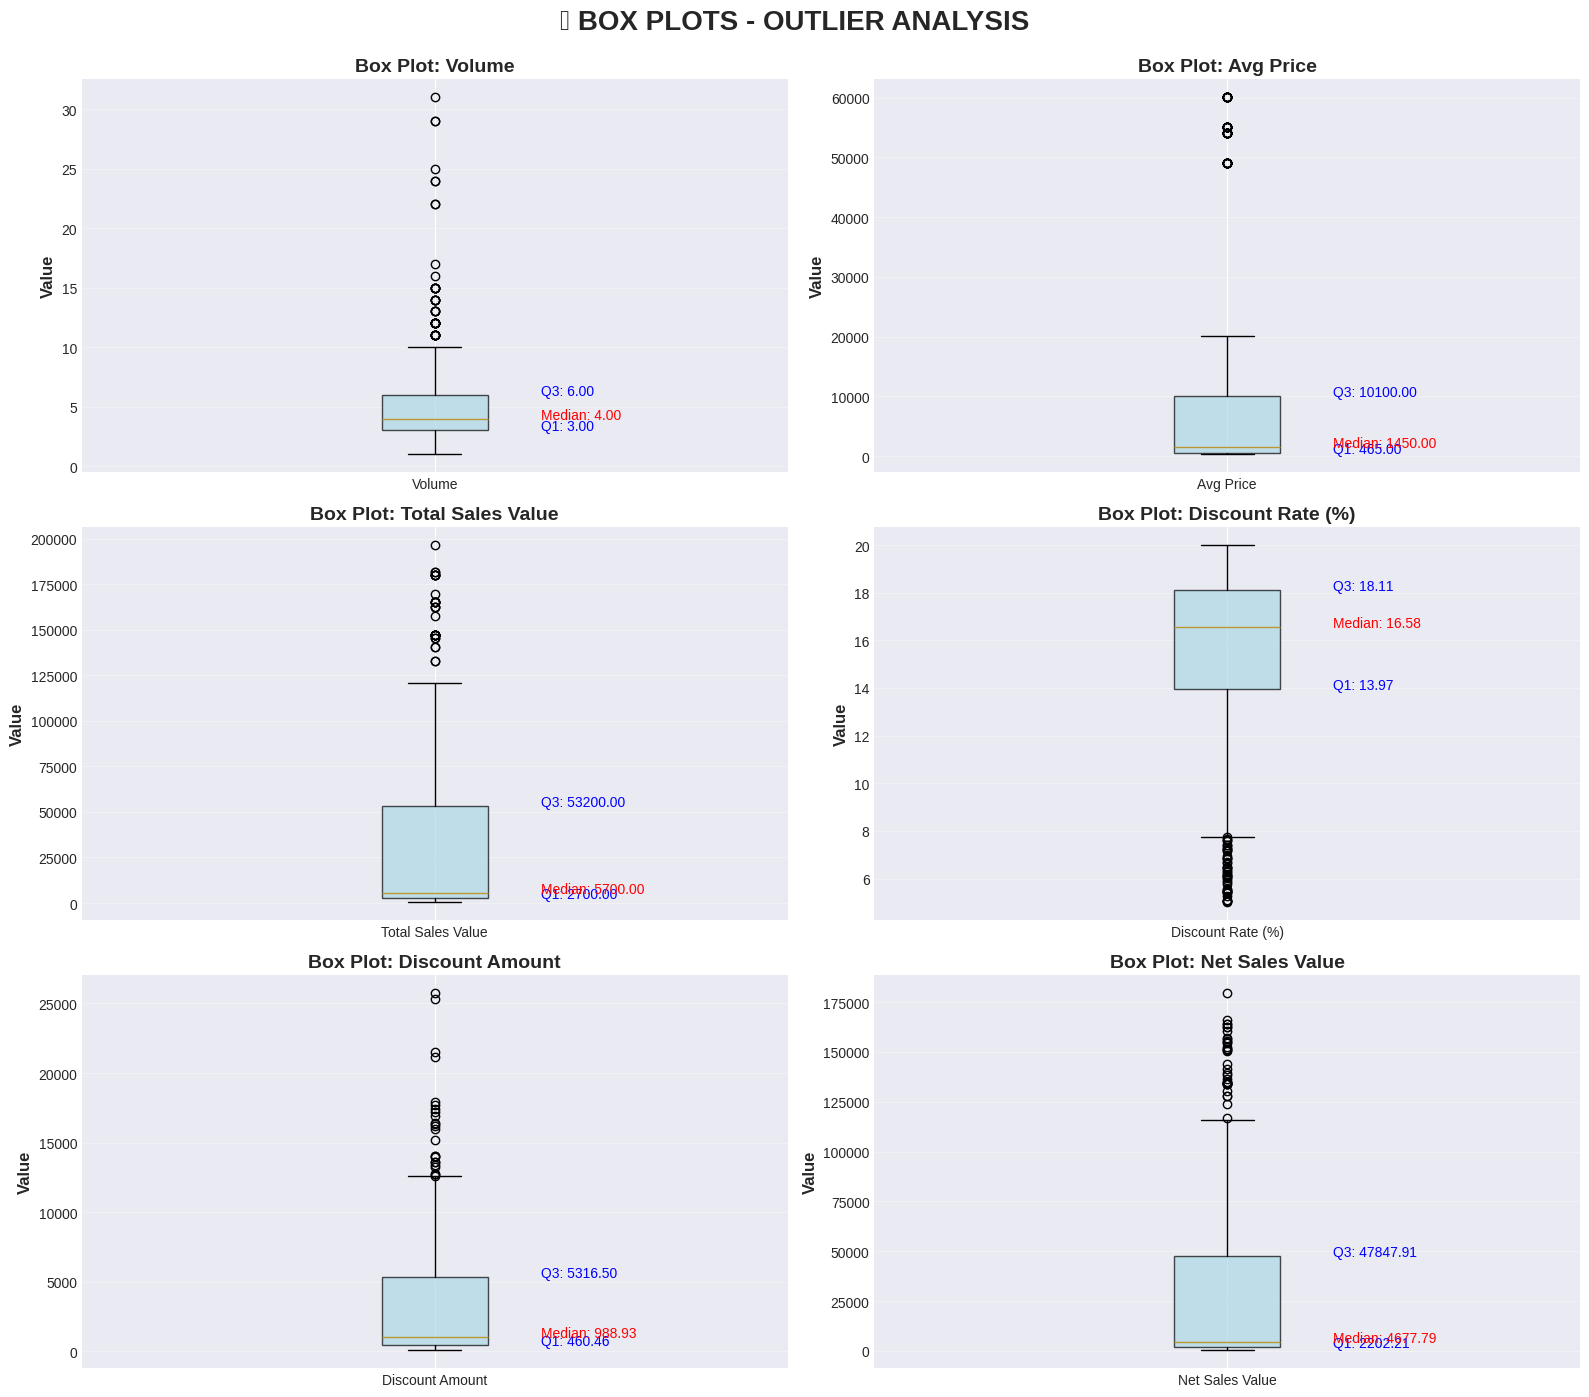


🔍 OUTLIER DETECTION (Using IQR Method):

Volume:
  - IQR: 3.00
  - Lower Fence: -1.50
  - Upper Fence: 10.50
  - Outliers: 44 (9.78% of data)
  - ⚠️ Contains 44 potential outliers

Avg Price:
  - IQR: 9635.00
  - Lower Fence: -13987.50
  - Upper Fence: 24552.50
  - Outliers: 60 (13.33% of data)
  - ⚠️ Contains 60 potential outliers

Total Sales Value:
  - IQR: 50500.00
  - Lower Fence: -73050.00
  - Upper Fence: 128950.00
  - Outliers: 36 (8.00% of data)
  - ⚠️ Contains 36 potential outliers

Discount Rate (%):
  - IQR: 4.15
  - Lower Fence: 7.74
  - Upper Fence: 24.34
  - Outliers: 45 (10.00% of data)
  - ⚠️ Contains 45 potential outliers

Discount Amount:
  - IQR: 4856.04
  - Lower Fence: -6823.59
  - Upper Fence: 12600.55
  - Outliers: 24 (5.33% of data)
  - ⚠️ Contains 24 potential outliers

Net Sales Value:
  - IQR: 45645.70
  - Lower Fence: -66266.35
  - Upper Fence: 116316.47
  - Outliers: 35 (7.78% of data)
  - ⚠️ Contains 35 potential outliers



In [36]:
# ==========================================
# SECTION 5: BOX PLOTS - OUTLIER DETECTION
# ==========================================

print("\n" + "="*60)
print("SECTION 5: BOX PLOTS - OUTLIER DETECTION")
print("="*60)

# Create box plots
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('📦 BOX PLOTS - OUTLIER ANALYSIS',
             fontsize=20, fontweight='bold', y=0.995)

for idx, col in enumerate(plot_cols):
    if col in df.columns:
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]

        # Create box plot
        bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        labels=[col])

        # Color the box
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)

        # Add statistical annotations
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        median = df[col].median()

        # Add text annotations
        ax.text(1.15, q1, f'Q1: {q1:.2f}', fontsize=10, color='blue')
        ax.text(1.15, median, f'Median: {median:.2f}', fontsize=10, color='red')
        ax.text(1.15, q3, f'Q3: {q3:.2f}', fontsize=10, color='blue')

        ax.set_ylabel('Value', fontsize=12, fontweight='bold')
        ax.set_title(f'Box Plot: {col}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Outlier detection
print("\n🔍 OUTLIER DETECTION (Using IQR Method):\n")

for col in plot_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100

        print(f"{col}:")
        print(f"  - IQR: {IQR:.2f}")
        print(f"  - Lower Fence: {lower_fence:.2f}")
        print(f"  - Upper Fence: {upper_fence:.2f}")
        print(f"  - Outliers: {outlier_count} ({outlier_pct:.2f}% of data)")

        if outlier_count > 0:
            print(f"  - ⚠️ Contains {outlier_count} potential outliers")
        else:
            print(f"  - ✓ No outliers detected")
        print()


SECTION 6: CATEGORICAL VARIABLE ANALYSIS


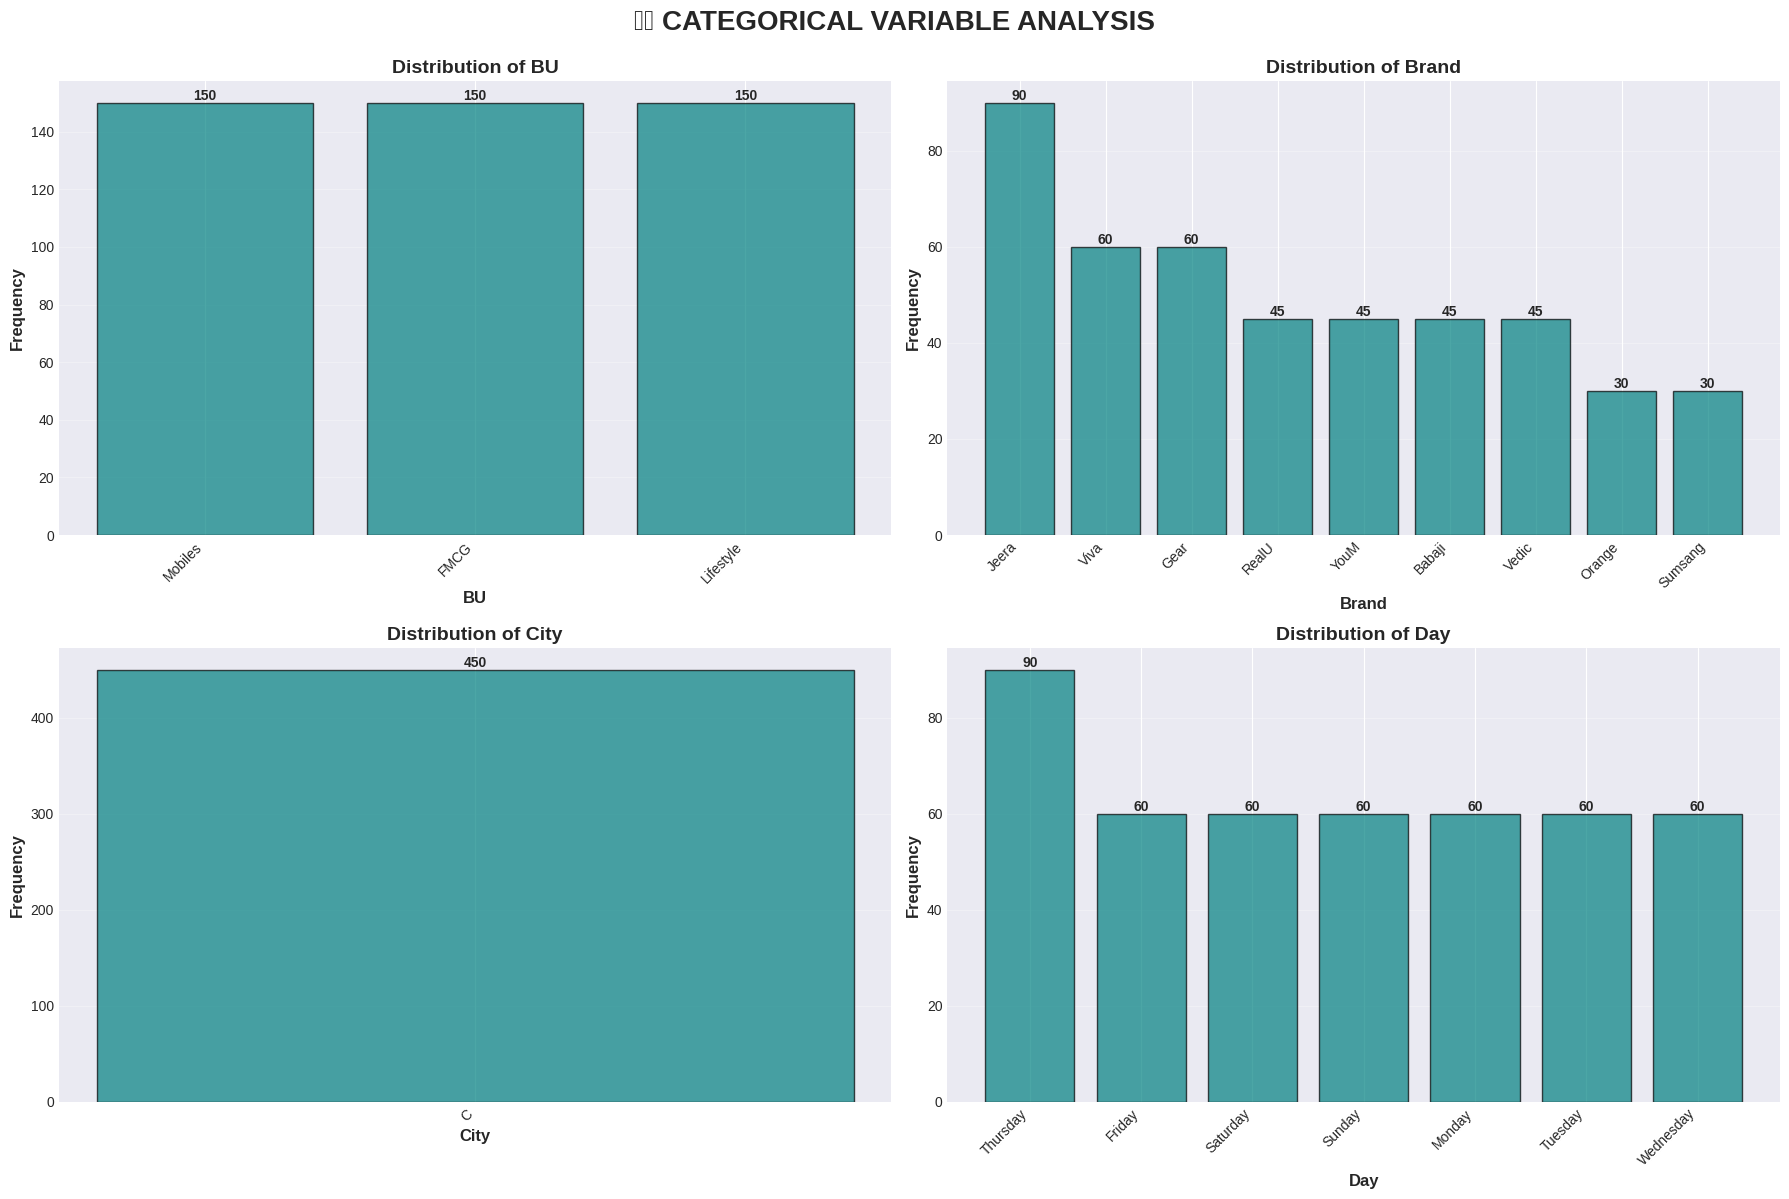


📊 CATEGORICAL VARIABLE INSIGHTS:


BU:
  Total Categories: 3
  Distribution:
    - Mobiles: 150 (33.33%)
    - FMCG: 150 (33.33%)
    - Lifestyle: 150 (33.33%)
  💡 Most Common: Mobiles (150 records)
  💡 Least Common: Lifestyle (150 records)

BRAND:
  Total Categories: 9
  Distribution:
    - Jeera: 90 (20.00%)
    - Viva: 60 (13.33%)
    - Gear: 60 (13.33%)
    - RealU: 45 (10.00%)
    - YouM: 45 (10.00%)
    - Babaji: 45 (10.00%)
    - Vedic: 45 (10.00%)
    - Orange: 30 (6.67%)
    - Sumsang: 30 (6.67%)
  💡 Most Common: Jeera (90 records)
  💡 Least Common: Sumsang (30 records)

CITY:
  Total Categories: 1
  Distribution:
    - C: 450 (100.00%)
  💡 Most Common: C (450 records)
  💡 Least Common: C (450 records)

DAY:
  Total Categories: 7
  Distribution:
    - Thursday: 90 (20.00%)
    - Friday: 60 (13.33%)
    - Saturday: 60 (13.33%)
    - Sunday: 60 (13.33%)
    - Monday: 60 (13.33%)
    - Tuesday: 60 (13.33%)
    - Wednesday: 60 (13.33%)
  💡 Most Common: Thursday (90 records)
  💡 L

In [37]:
# ==========================================
# SECTION 6: CATEGORICAL ANALYSIS
# ==========================================

print("\n" + "="*60)
print("SECTION 6: CATEGORICAL VARIABLE ANALYSIS")
print("="*60)

# Analyze key categorical columns
cat_analysis_cols = ['BU', 'Brand', 'City', 'Day']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🏷️ CATEGORICAL VARIABLE ANALYSIS',
             fontsize=20, fontweight='bold', y=0.995)

for idx, col in enumerate(cat_analysis_cols):
    if col in df.columns:
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]

        # Count frequencies
        value_counts = df[col].value_counts()

        # Create bar chart
        bars = ax.bar(range(len(value_counts)), value_counts.values,
                      color='teal', alpha=0.7, edgecolor='black')

        # Customize
        ax.set_xticks(range(len(value_counts)))
        ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
        ax.set_xlabel(col, fontsize=12, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print categorical insights
print("\n📊 CATEGORICAL VARIABLE INSIGHTS:\n")

for col in cat_analysis_cols:
    if col in df.columns:
        value_counts = df[col].value_counts()
        total = len(df)

        print(f"\n{col.upper()}:")
        print(f"  Total Categories: {len(value_counts)}")
        print(f"  Distribution:")

        for category, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"    - {category}: {count} ({percentage:.2f}%)")

        # Most and least common
        most_common = value_counts.index[0]
        least_common = value_counts.index[-1]
        print(f"  💡 Most Common: {most_common} ({value_counts[most_common]} records)")
        print(f"  💡 Least Common: {least_common} ({value_counts[least_common]} records)")



SECTION 7: CORRELATION ANALYSIS


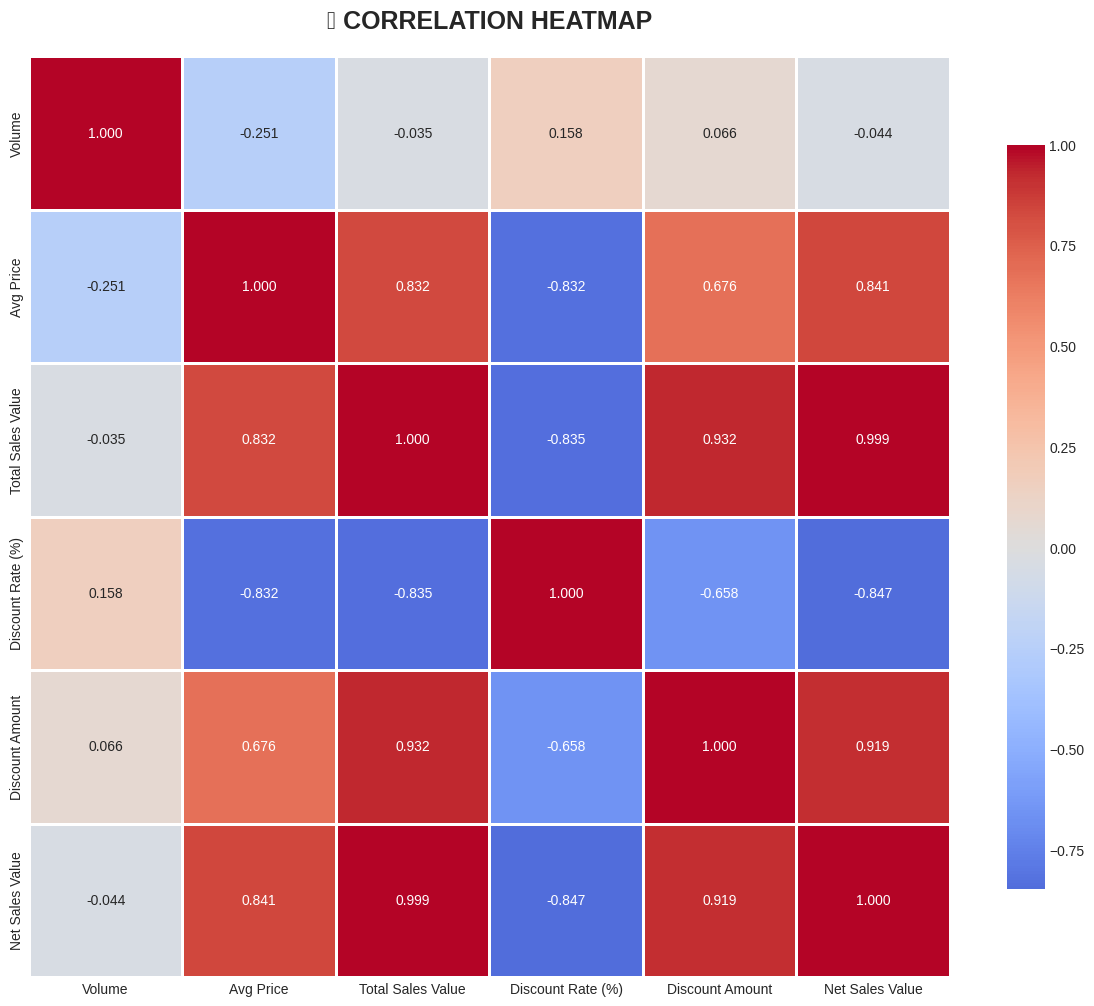


🔗 KEY CORRELATIONS:

  - Avg Price ↔ Total Sales Value: 0.832 (Strong Positive)
  - Avg Price ↔ Discount Rate (%): -0.832 (Strong Negative)
  - Avg Price ↔ Net Sales Value: 0.841 (Strong Positive)
  - Total Sales Value ↔ Discount Rate (%): -0.835 (Strong Negative)
  - Total Sales Value ↔ Discount Amount: 0.932 (Strong Positive)
  - Total Sales Value ↔ Net Sales Value: 0.999 (Strong Positive)
  - Discount Rate (%) ↔ Net Sales Value: -0.847 (Strong Negative)
  - Discount Amount ↔ Net Sales Value: 0.919 (Strong Positive)


In [38]:
# ==========================================
# SECTION 7: CORRELATION ANALYSIS
# ==========================================

print("\n" + "="*60)
print("SECTION 7: CORRELATION ANALYSIS")
print("="*60)

# Select numerical columns for correlation
corr_cols = ['Volume', 'Avg Price', 'Total Sales Value',
             'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
corr_data = df[corr_cols]

# Calculate correlation matrix
correlation_matrix = corr_data.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f',
            cmap='coolwarm', center=0,
            square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('🔥 CORRELATION HEATMAP', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔗 KEY CORRELATIONS:\n")

# Find strong correlations
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:  # Strong correlation threshold
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"  - {col1} ↔ {col2}: {corr_val:.3f}", end="")
            if corr_val > 0:
                print(" (Strong Positive)")
            else:
                print(" (Strong Negative)")

In [39]:
# ==========================================
# SECTION 8: BUSINESS INSIGHTS
# ==========================================

print("\n" + "="*60)
print("SECTION 8: KEY BUSINESS INSIGHTS")
print("="*60)

# Calculate key business metrics
total_sales = df['Total Sales Value'].sum()
total_discounts = df['Discount Amount'].sum()
net_sales = df['Net Sales Value'].sum()
avg_discount_rate = df['Discount Rate (%)'].mean()
total_volume = df['Volume'].sum()

print(f"""
💰 SALES METRICS:
  - Total Sales Value: ₹{total_sales:,.2f}
  - Total Discounts Given: ₹{total_discounts:,.2f}
  - Net Sales Value: ₹{net_sales:,.2f}
  - Average Discount Rate: {avg_discount_rate:.2f}%
  - Total Units Sold: {total_volume:,}

📊 TOP PERFORMING:
""")

# Top products by sales
print("  Top 5 Products by Total Sales:")
top_products = df.groupby('Model')['Total Sales Value'].sum().sort_values(ascending=False).head()
for idx, (product, sales) in enumerate(top_products.items(), 1):
    print(f"    {idx}. {product}: ₹{sales:,.2f}")

# Top business units
print("\n  Sales by Business Unit:")
bu_sales = df.groupby('BU')['Total Sales Value'].sum().sort_values(ascending=False)
for bu, sales in bu_sales.items():
    pct = (sales / total_sales) * 100
    print(f"    - {bu}: ₹{sales:,.2f} ({pct:.1f}%)")



SECTION 8: KEY BUSINESS INSIGHTS

💰 SALES METRICS:
  - Total Sales Value: ₹15,215,776.00
  - Total Discounts Given: ₹1,505,924.74
  - Net Sales Value: ₹13,709,851.26
  - Average Discount Rate: 15.16%
  - Total Units Sold: 2,280

📊 TOP PERFORMING:

  Top 5 Products by Total Sales:
    1. S-20: ₹2,111,300.00
    2. O-11: ₹1,983,300.00
    3. O-10: ₹1,928,500.00
    4. RU-10: ₹1,730,300.00
    5. YM-99 Plus: ₹1,567,800.00

  Sales by Business Unit:
    - Mobiles: ₹13,920,100.00 (91.5%)
    - Lifestyle: ₹898,469.00 (5.9%)
    - FMCG: ₹397,207.00 (2.6%)


In [40]:
# ==========================================
# SECTION 9: CONCLUSIONS & RECOMMENDATIONS
# ==========================================

print("\n" + "="*60)
print("SECTION 9: CONCLUSIONS & RECOMMENDATIONS")
print("="*60)

print("""
✅ KEY FINDINGS:

1. DESCRIPTIVE STATISTICS:
   - Calculated mean, median, mode, and standard deviation for all numerical variables
   - Identified central tendencies and variability in sales, discounts, and volumes

2. DISTRIBUTION PATTERNS:
   - Analyzed frequency distributions using histograms
   - Identified skewness and modality in data distributions
   - Detected patterns in pricing and discount strategies

3. OUTLIER DETECTION:
   - Used box plots and IQR method to identify extreme values
   - Detected unusual transactions requiring attention
   - Quantified outlier percentages for each metric

4. CATEGORICAL INSIGHTS:
   - Analyzed distribution across business units, brands, and products
   - Identified dominant categories and market representation
   - Revealed opportunities for category expansion

5. CORRELATIONS:
   - Strong positive correlations between volume and total sales
   - Relationship between discount rates and net sales
   - Insights for pricing optimization

🎯 RECOMMENDATIONS:

1. DATA QUALITY:
   - Investigate and handle identified outliers
   - Address any missing values in categorical variables

2. PRICING STRATEGY:
   - Review discount policies (avg {avg_discount_rate:.2f}%)
   - Optimize discount rates based on product categories

3. INVENTORY MANAGEMENT:
   - Focus on high-volume products
   - Balance stock across business units

4. BUSINESS FOCUS:
   - Leverage insights from top-performing categories
   - Explore growth opportunities in underrepresented segments

5. FURTHER ANALYSIS:
   - Conduct time-series analysis for trends
   - Perform customer segmentation
   - Build predictive models for sales forecasting
   - Analyze seasonal patterns in discount effectiveness

""")

print("="*60)
print("✨ ANALYSIS COMPLETE!")
print("="*60)


SECTION 9: CONCLUSIONS & RECOMMENDATIONS

✅ KEY FINDINGS:

1. DESCRIPTIVE STATISTICS:
   - Calculated mean, median, mode, and standard deviation for all numerical variables
   - Identified central tendencies and variability in sales, discounts, and volumes
   
2. DISTRIBUTION PATTERNS:
   - Analyzed frequency distributions using histograms
   - Identified skewness and modality in data distributions
   - Detected patterns in pricing and discount strategies

3. OUTLIER DETECTION:
   - Used box plots and IQR method to identify extreme values
   - Detected unusual transactions requiring attention
   - Quantified outlier percentages for each metric

4. CATEGORICAL INSIGHTS:
   - Analyzed distribution across business units, brands, and products
   - Identified dominant categories and market representation
   - Revealed opportunities for category expansion

5. CORRELATIONS:
   - Strong positive correlations between volume and total sales
   - Relationship between discount rates and net sales